# Regressão Linear

## Regressão para Previsão de Perdas

Este notebook usa regressão linear para prever o número de perdas de isqueiros por usuário.
- Usa dados reais do LighterTracker.
- 4 variáveis X (input) e 1 variável Y (output).
- Objetivo: Demonstrar funcionalidade do protótipo para prever perdas e personalizar alertas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [3]:
# Configurações para visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

In [4]:
# Definir semente para reprodutibilidade
np.random.seed(42)

In [6]:

# Carregar tabelas
data_dir = '/content/'
dfs = {
    'usuarios': pd.read_csv(data_dir + 'usuarios.csv'),
    'utilizacao': pd.read_csv(data_dir + 'utilizacao.csv'),
    'historico_localizacao': pd.read_csv(data_dir + 'historico_localizacao.csv'),
    'isqueiros_usuario': pd.read_csv(data_dir + 'isqueiros_usuario.csv')
}

In [7]:
# Converter colunas de data
dfs['usuarios']['DataNascimento'] = pd.to_datetime(dfs['usuarios']['DataNascimento'])
dfs['utilizacao']['DataHoraUso'] = pd.to_datetime(dfs['utilizacao']['DataHoraUso'])
dfs['historico_localizacao']['DataHoraRegistro'] = pd.to_datetime(dfs['historico_localizacao']['DataHoraRegistro'])


## 2. Preparação dos Dados

Objetivo: Criar uma base com 4 variáveis X e 1 variável Y.
- X (variáveis explicativas):
- idade: Calculada a partir de DataNascimento (usuarios).
- frequencia_uso: Número total de usos por usuário (utilizacao).
- n_isqueiros: Número de isqueiros comprados (isqueiros_usuario).
- renda_familiar: Renda familiar do usuário (usuarios).
- Y (variável alvo): n_perdas (número de eventos "Perdido" por usuário, de historico_localizacao).

In [8]:
# Calcular número de perdas por usuário
perdas = dfs['historico_localizacao'][dfs['historico_localizacao']['TipoEvento'] == 'Perdido']
perdas = perdas.merge(dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID')
perdas_por_usuario = perdas.groupby('UsuarioID').size().reset_index(name='n_perdas')

In [9]:
# Calcular frequência de uso por usuário
frequencia_uso = dfs['utilizacao'].merge(
    dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID'
).groupby('UsuarioID').size().reset_index(name='frequencia_uso')

In [10]:
# Calcular número de isqueiros por usuário
n_isqueiros = dfs['isqueiros_usuario'].groupby('UsuarioID').size().reset_index(name='n_isqueiros')

In [22]:
n_isqueiros.head()

,UsuarioID,n_isqueiros
0,1,7
1,2,5
2,3,2
3,4,7
4,5,9


In [11]:
# Criar base de dados
dados_regressao = dfs['usuarios'][['UsuarioID', 'DataNascimento', 'RendaFamiliar']].copy()
dados_regressao['idade'] = (pd.to_datetime('2025-07-30') - dados_regressao['DataNascimento']).dt.days // 365
dados_regressao = dados_regressao.merge(frequencia_uso, on='UsuarioID', how='left').fillna({'frequencia_uso': 0})
dados_regressao = dados_regressao.merge(n_isqueiros, on='UsuarioID', how='left').fillna({'n_isqueiros': 0})
dados_regressao = dados_regressao.merge(perdas_por_usuario, on='UsuarioID', how='left').fillna({'n_perdas': 0})
dados_regressao = dados_regressao[['idade', 'frequencia_uso', 'n_isqueiros', 'RendaFamiliar', 'n_perdas']].rename(
    columns={'RendaFamiliar': 'renda_familiar'}
)

In [13]:
# Visualizar
print("\n### Base de Dados")
display(dados_regressao.head())


### Base de Dados


,idade,frequencia_uso,n_isqueiros,renda_familiar,n_perdas
0,23,14.0,7.0,1991.88,1.0
1,71,5.0,5.0,4356.30,1.0
2,74,3.0,2.0,2983.43,0.0
3,64,6.0,7.0,3554.65,1.0
4,35,17.0,9.0,2991.64,1.0


## 3. Separar X e Y

In [14]:

# Objetivo: Definir variáveis explicativas (X) e alvo (Y).
X = dados_regressao[['idade', 'frequencia_uso', 'n_isqueiros', 'renda_familiar']]
y = dados_regressao['n_perdas']

## 4. Dividir em Treino e Teste

In [17]:
# Objetivo: Separar 80% dos dados para treino e 20% para teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Treinamento do Modelo

In [18]:
# Objetivo: Treinar uma regressão linear para prever n_perdas.
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

# Exibir coeficientes
print("\n### Coeficientes do Modelo")
print(f"Intercepto: {model_reg.intercept_:.2f}")
for var, coef in zip(X.columns, model_reg.coef_):
    print(f"{var}: {coef:.2f}")


### Coeficientes do Modelo
Intercepto: -0.01
idade: 0.00
frequencia_uso: -0.00
n_isqueiros: 0.10
renda_familiar: 0.00


## 6. Avaliação do Modelo

In [19]:
# Objetivo: Avaliar o desempenho com R² e MAE.
y_pred = model_reg.predict(X_test)

# Calcular métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n### Avaliação")
print(f"R² (variância explicada): {r2:.3f}")
print(f"MAE (erro médio): {mae:.2f} perdas")


### Avaliação
R² (variância explicada): 0.086
MAE (erro médio): 0.63 perdas


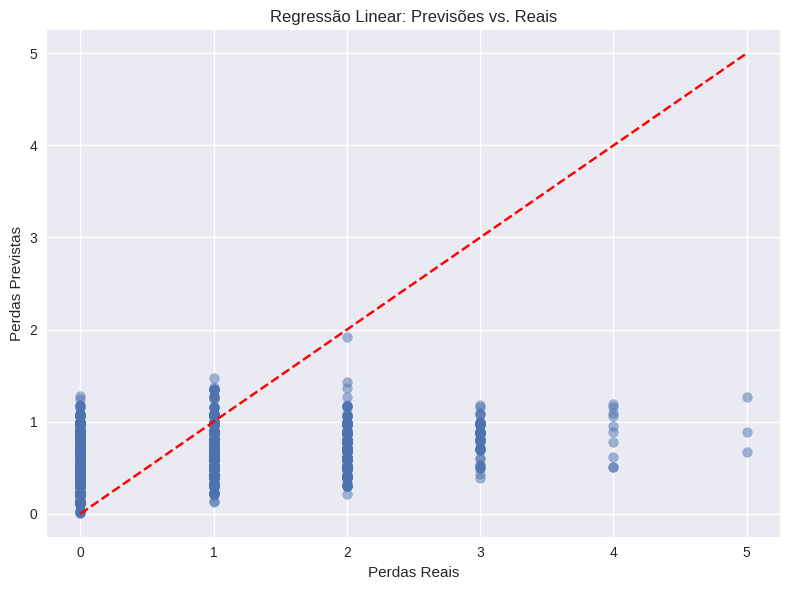

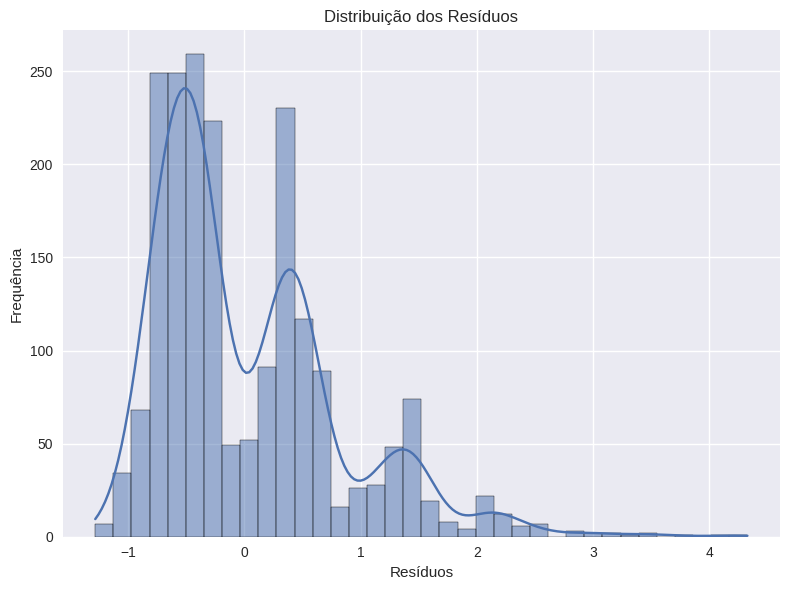

In [21]:
# Visualizar previsões vs. reais
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Perdas Reais')
plt.ylabel('Perdas Previstas')
plt.title('Regressão Linear: Previsões vs. Reais')
plt.tight_layout()
plt.show()

# Visualize the residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.title('Distribuição dos Resíduos')
plt.tight_layout()
plt.show()